# Несмещенность, состоятельность, асимптотическая нормальность оценок


**Исполнитель (ФИО):** Липунцов Антон Юрьевич

---

Здравствуйте! В этом практикуме вам предстоит познакомиться с некоторыми свойствами статистических оценок

Напомним, вы научились некоторым методам построения статистических оценок по выборке: ОММ, ОМП, ОМС

ОММ удобна тем, что мы обычно знаем теоретические моменты распределения до любого порядка $k$

ОМП и ОМС основаны на максимизации вероятности выпадения именно данной выборки, что само по себе хорошее свойство

Возникает вопрос, насколько такие или любые другие виды оценок $\hat{\theta}$ действительно хорошо приближают истинный параметр распределения $\theta$?

Ответить на этот вопрос могут свойства оценок, некоторые из которых мы изучим :

1. Оценка называется [несмещенной](https://ru.wikipedia.org/wiki/%D0%9D%D0%B5%D1%81%D0%BC%D0%B5%D1%89%D1%91%D0%BD%D0%BD%D0%B0%D1%8F_%D0%BE%D1%86%D0%B5%D0%BD%D0%BA%D0%B0), если $\mathbb{E}[\hat{\theta}]=\theta$, и асимптотически несмещенной, если $\mathbb{E}[\hat{\theta}]\rightarrow\theta$
2. Оценка называется [состоятельной](https://ru.wikipedia.org/wiki/%D0%A1%D0%BE%D1%81%D1%82%D0%BE%D1%8F%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D0%B0%D1%8F_%D0%BE%D1%86%D0%B5%D0%BD%D0%BA%D0%B0), если $\hat{\theta}\xrightarrow{P}\theta$
3. Оценка называется [асимптотически нормальной](https://ru.wikipedia.org/wiki/%D0%90%D1%81%D0%B8%D0%BC%D0%BF%D1%82%D0%BE%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8_%D0%BD%D0%BE%D1%80%D0%BC%D0%B0%D0%BB%D1%8C%D0%BD%D0%B0%D1%8F_%D0%BE%D1%86%D0%B5%D0%BD%D0%BA%D0%B0), если $\sqrt{n}(\hat{\theta}-\theta)\xrightarrow{d} Z\sim\mathcal{N}(0,\sigma^{2}(\theta))$

Выполнение этих свойств гарантирует, что, при достаточном размере выборки, оценка будет близка к истинному значению параметра

## Задача 1

Для численной проверки несмещенности оценки можно воспользоваться методом Монте-Карло:
1. Зафиксируем достаточно большое число $M$
2. Сгенерируем $M$ выборок объема $n$
3. Построим $M$ оценок и возьмем их среднее, вычтем истинное значение параметра
4. Нарисуем график зависимости этой величины от $n$

Несмещенная оценка зачастую колеблется около нуля и стремится к нему, смещенная в общем, но асимптотически несмещенная оценка будет стремиться к нулю с ростом $n$, а смещенная оценка стремится к ненулевой величине (смещению оценки) в общем случае, зависящей от $\theta$

Проверьте несмещенность следующих оценок параметра $\theta$ для распределения $\mathcal{N}(0, \theta^{2})$
1. ОМП
2. $\sqrt{\frac{1}{n-1}\sum\limits_{i=1}^{n}X_{i}^{2}}$
3. $c_{1}\sum\limits_{i=1}^{n}|X_{i}|$
4. ОМC

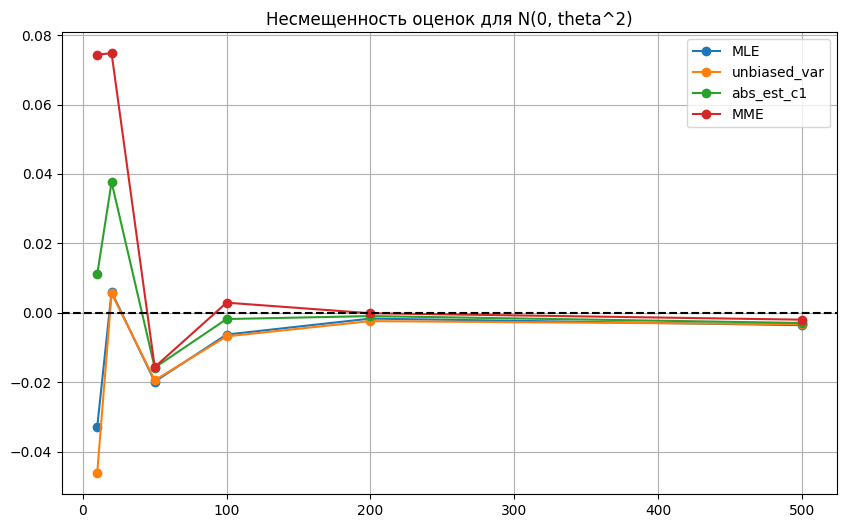

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize

theta_true = 2.0

def MLE(x):
    return np.sqrt(np.mean(x**2))

def unbiased_var(x):
    return np.sqrt(np.var(x, ddof=1))

def abs_est(x, c1):
    return c1 * np.sum(np.abs(x))

def MME(x):
    med_abs = np.median(np.abs(x))
    q = stats.norm.ppf(0.75)
    return med_abs / q

c1_opt = np.sqrt(np.pi/2)

M = 500
n_values = [10, 20, 50, 100, 200, 500]
biases = {'MLE': [], 'unbiased_var': [], 'abs_est_c1': [], 'MME': []}


for n in n_values:
    biases_n = {'MLE': 0, 'unbiased_var': 0, 'abs_est_c1': 0, 'MME': 0}
    for _ in range(M):
        sample = np.random.normal(0, theta_true, n)
        biases_n['MLE'] += MLE(sample) - theta_true
        biases_n['unbiased_var'] += unbiased_var(sample) - theta_true
        biases_n['abs_est_c1'] += abs_est(sample, c1_opt/n) - theta_true   # c1 = sqrt(pi/2)/n
        biases_n['MME'] += MME(sample) - theta_true
    for key in biases_n:
        biases[key].append(biases_n[key] / M)

plt.figure(figsize=(10,6))
for key, bias in biases.items():
    plt.plot(n_values, bias, marker='o', label=key)
plt.axhline(0, color='black', linestyle='--')
plt.title('Несмещенность оценок для N(0, theta^2)')
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:** Какие оценки оказались несмещенными? При каком значении параметра $c_{1}$ оценка является несмещенной? Какая оценка лучше угадывает параметр? Сравните практические результаты с теоретическими рассчётами

Оценки ОМП и $\sqrt{\frac{1}{n-1}\sum\limits_{i=1}^{n}X_{i}^{2}}$ смещены (различаются только множителями). Оценка ОМС тоже смещена.
Оценка $c_{1}\sum\limits_{i=1}^{n}|X_{i}|$ несмещённая при $c_1 = \frac{\sqrt{\pi/2}}{n}$, так как $E[X] = θ \sqrt\frac{2}{π}$  
$E[\sum{X}] = n*θ\sqrt\frac{2}{π}$  
$E[\hat{θ}]=c1*n*θ\sqrt\frac{2}{π} = θ$  
$c_1 = \frac{\sqrt{\pi/2}}{n}$.

Проверьте дополнительно несмещенность оценок ОММ, ОМП и ОМС для распределений из прошлого практикума:
1. $\text{Г}(5, \theta)$
2. $B(\theta, 5)$

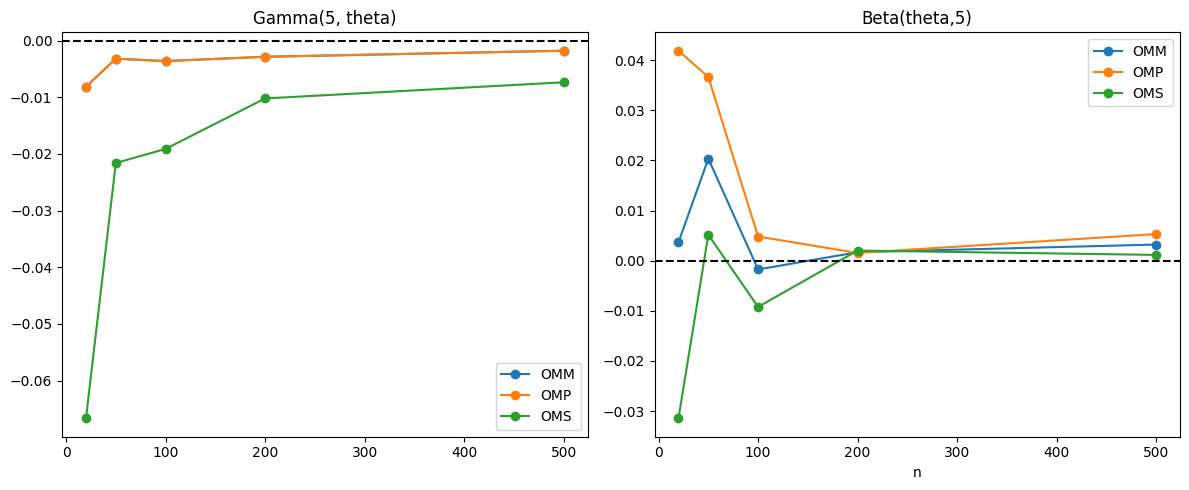

In [2]:
def gamma_mom(x):
    return np.mean(x) / 5

def gamma_mle(x):
    return np.mean(x) / 5

def gamma_mme2(x):
    return np.sqrt(np.var(x, ddof=0) / 5)

def beta_mom(x):
    mean_x = np.mean(x)
    if mean_x <= 0 or mean_x >= 1:
        return np.nan
    return 5 * mean_x / (1 - mean_x)

def beta_mle(x):
    def neg_log_lik(theta):
        if theta <= 0:
            return 1e10
        return -np.sum(stats.beta.logpdf(x, theta, 5))
    res = optimize.minimize(neg_log_lik, x0=1.0, bounds=[(0.01, None)])
    return res.x[0]

def beta_mme2(x):
    def eq(theta):
        if theta <= 0:
            return 1e10
        e_x2 = (theta*(theta+1)) / ((theta+5)*(theta+6))
        return e_x2 - np.mean(x**2)
    try:
        theta0 = beta_mom(x) if not np.isnan(beta_mom(x)) else 1.0
        sol = optimize.root_scalar(eq, bracket=[0.01, 100], method='bisect')
        return sol.root
    except:
        return np.nan

theta_gamma_true = 2.0
theta_beta_true = 2.0

n_vals = [20, 50, 100, 200, 500]
M = 300

bias_gamma = {'OMM': [], 'OMP': [], 'OMS': []}
bias_beta = {'OMM': [], 'OMP': [], 'OMS': []}

np.random.seed(42)
for n in n_vals:
    bg = {'OMM':0, 'OMP':0, 'OMS':0}
    bb = {'OMM':0, 'OMP':0, 'OMS':0}
    for _ in range(M):
        samp_g = np.random.gamma(5, theta_gamma_true, n)
        bg['OMM'] += gamma_mom(samp_g) - theta_gamma_true
        bg['OMP'] += gamma_mle(samp_g) - theta_gamma_true
        bg['OMS'] += gamma_mme2(samp_g) - theta_gamma_true
        samp_b = np.random.beta(theta_beta_true, 5, n)
        bb['OMM'] += beta_mom(samp_b) - theta_beta_true
        bb['OMP'] += beta_mle(samp_b) - theta_beta_true
        bb['OMS'] += beta_mme2(samp_b) - theta_beta_true
    for k in bg:
        bias_gamma[k].append(bg[k]/M)
        bias_beta[k].append(bb[k]/M)

fig, axes = plt.subplots(1,2, figsize=(12,5))
for k in bias_gamma:
    axes[0].plot(n_vals, bias_gamma[k], marker='o', label=k)
axes[0].axhline(0, linestyle='--', color='k')
axes[0].set_title('Gamma(5, theta)')
axes[0].legend()
for k in bias_beta:
    axes[1].plot(n_vals, bias_beta[k], marker='o', label=k)
axes[1].axhline(0, linestyle='--', color='k')
axes[1].set_title('Beta(theta,5)')
axes[1].set_xlabel('n')
axes[1].legend()
plt.tight_layout()
plt.show()

**Вопрос:** Все ли методы дали несмещеные оценки? Зависит ли то, является оценка несмещенной или нет, от значения параметра? Ответ поясните

Для гамма-распределения оценки ОММ и ОМП совпадают и являются несмещёнными. Оценка ОМС смещена. Для бета-распределения все три оценки смещены, однако с ростом n смещение уменьшается.
Несмещённость может зависеть от параметра.

## Задача 2

Для численной проверки состоятельности оценки необходимо вспомнить [сходимость по мере](https://ru.wikipedia.org/wiki/%D0%A1%D1%85%D0%BE%D0%B4%D0%B8%D0%BC%D0%BE%D1%81%D1%82%D1%8C_%D0%BF%D0%BE_%D0%BC%D0%B5%D1%80%D0%B5#%D0%A1%D1%85%D0%BE%D0%B4%D0%B8%D0%BC%D0%BE%D1%81%D1%82%D1%8C_%D0%BF%D0%BE_%D0%B2%D0%B5%D1%80%D0%BE%D1%8F%D1%82%D0%BD%D0%BE%D1%81%D1%82%D0%B8):
1. Зафиксируем некоторое число $\varepsilon$ и достаточно большое число $M$
2. Сгенерируем $M$ выборок объема $n$
3. Построим $M$ оценок и посчитаем долю тех, для которых верно $|\hat{\theta}-\theta|>\varepsilon$
3. Нарисуем график зависимости этой величины от $n$

Для состоятельной оценки верно, что, какой бы мы ни взяли $\varepsilon$, доля таких выборок должна стремиться к нулю с ростом $n$

Проверьте на состоятельность численно оценки из предыдущей задачи. Постройте графики при разных $\varepsilon$

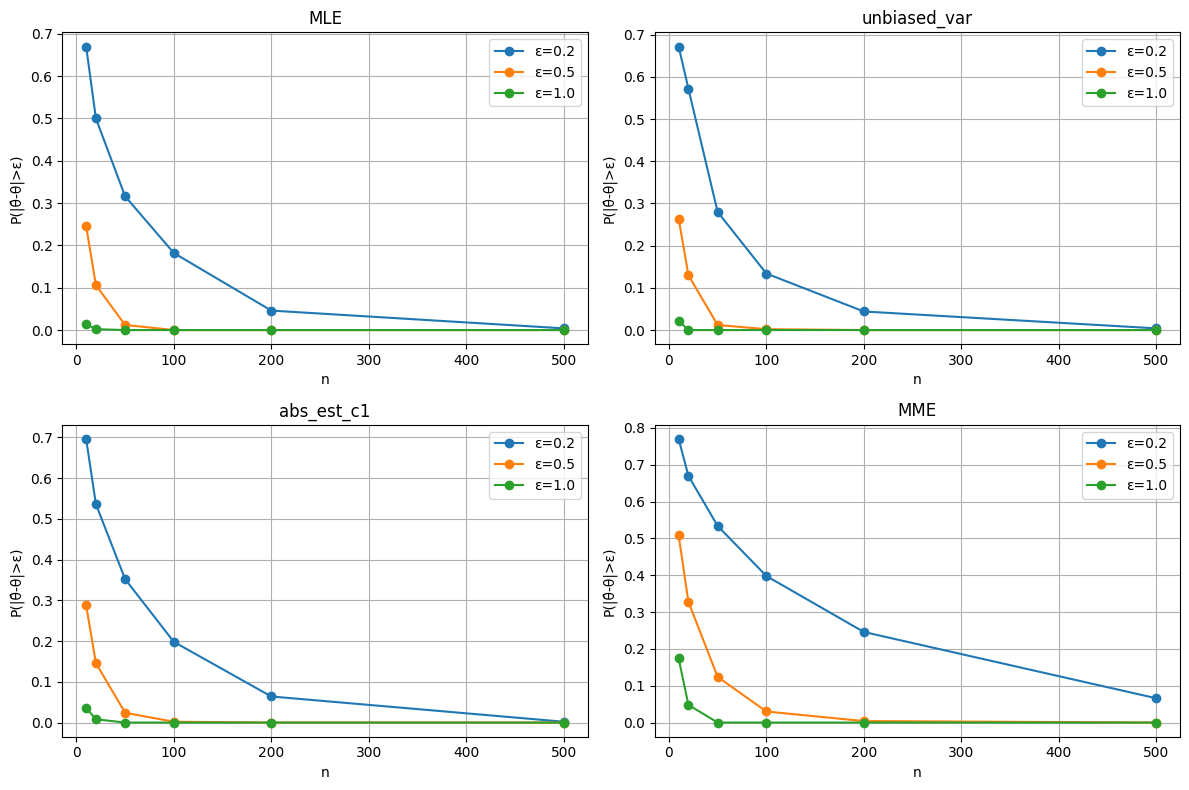

In [9]:
def check_consistency(estimator, true_theta, n_values, epsilons, M=500, args=()):
    results = {eps: [] for eps in epsilons}
    for n in n_values:
        for eps in epsilons:
            count = 0
            for _ in range(M):
                sample = np.random.normal(0, true_theta, n)
                est = estimator(sample, *args)
                if np.abs(est - true_theta) > eps:
                    count += 1
            results[eps].append(count / M)
    return results

n_vals = [10, 20, 50, 100, 200, 500]
eps_list = [0.2, 0.5, 1.0]
M = 500

estimators = {
    'MLE': MLE,
    'unbiased_var': unbiased_var,
    'abs_est_c1': lambda x: abs_est(x, c1_opt/len(x)),
    'MME': MME
}

plt.figure(figsize=(12,8))
for i, (name, est) in enumerate(estimators.items()):
    res = check_consistency(est, theta_true, n_vals, eps_list, M)
    plt.subplot(2,2,i+1)
    for eps in eps_list:
        plt.plot(n_vals, res[eps], marker='o', label=f'ε={eps}')
    plt.xlabel('n')
    plt.ylabel('P(|θ̂-θ|>ε)')
    plt.title(name)
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

**Вопрос:** Какие оценки оказались состоятельными? Зависит ли результат сходимости от $\varepsilon$? Ответ поясните

Все четыре оценки являются состоятельными: для каждого ε доля выборок, где ошибка превышает ε, стремится к нулю с ростом n.
Результат сходимости зависит от ε: при меньших ε доля ошибок выше при малых n, но всё равно стремится к нулю. Это соответствует определению сходимости по вероятности: для любого ε > 0 вероятность отклонения более ε должна стремиться к 0.

## Задача 3

Для предположения асимптотической нормальности оценки можно воспользоваться гистограммой:
1. Зафиксируем достаточно большое число $M$
2. Сгенерируем $M$ выборок объема $n$
3. Построим $M$ оценок и посчитаем величину $\sqrt{n}(\hat{\theta}-\theta)$
3. Нарисуем ее гистограмму и сравним с нормальной плотностью

Для асимптотически нормальной оценки верно, что эта вычисленная величина стремится к нормальному распределению с нулевым матожиданием и дисперсией $\sigma^{2}(\theta)$  с ростом $n$

Посмотрите при помощи гистограммы, какие оценки из предыдущей задачи могут быть асимптотически нормальными. Изобразите гистограмму и кривую нормального распределения с несмещенной выборочной дисперсией и, там где возможно, теоретической дисперсией оценки

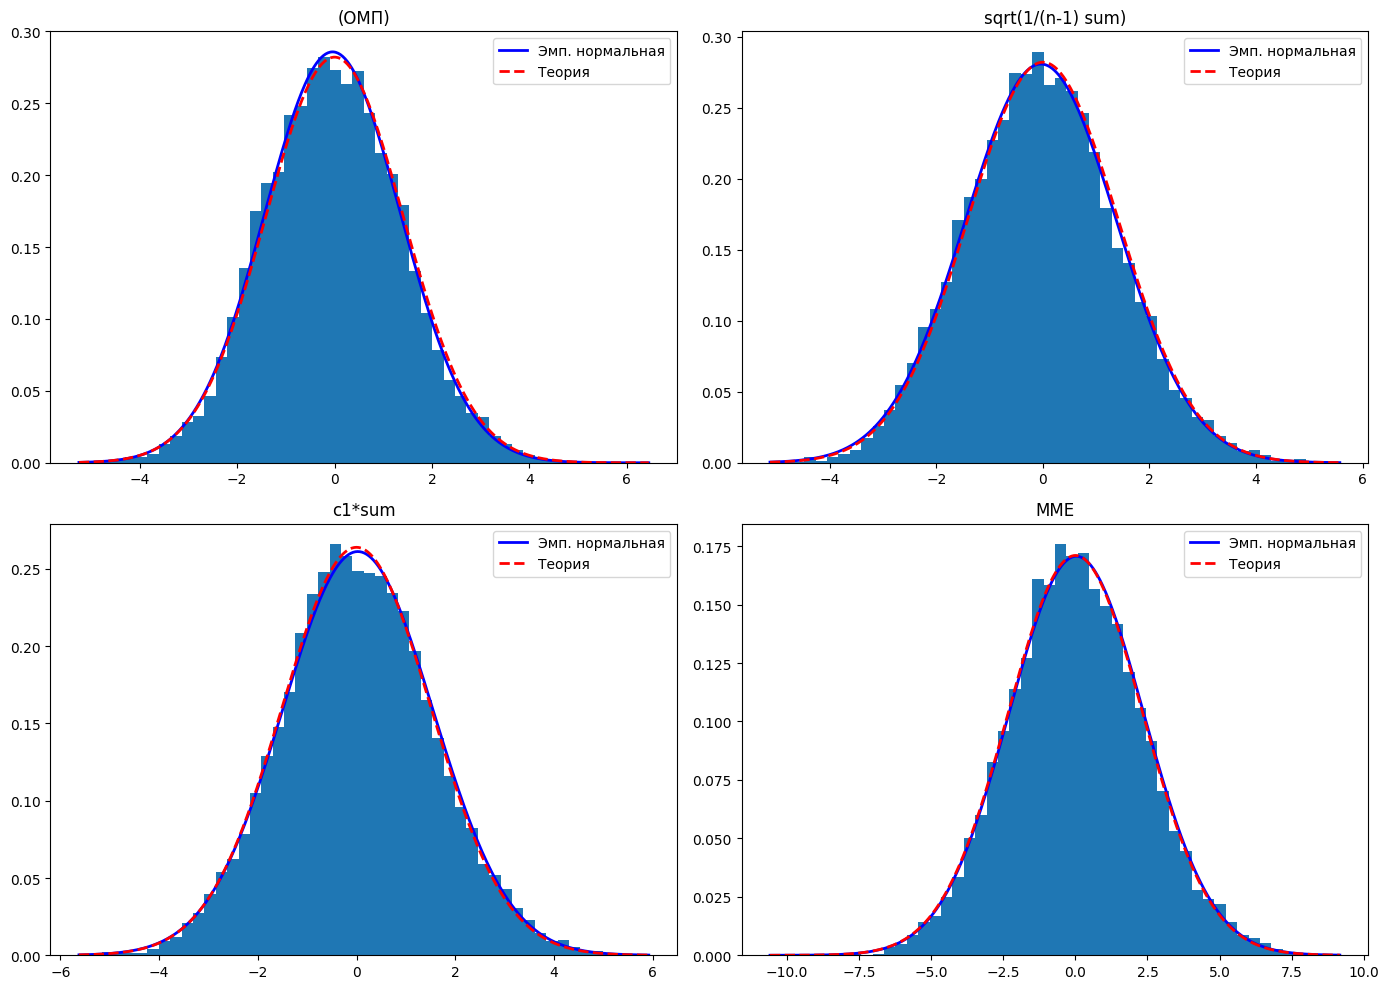

In [24]:
M = 10000
n = 300

estimators = {
    'MLE': MLE,
    'unbiased_var': unbiased_var,
    'abs_est_с1': lambda x: abs_est(x, c1_opt / len(x)),
    'MME': MME
}

theoretical_vars = {
    'MLE': theta_true**2 / 2,
    'unbiased_var': theta_true**2 / 2,
    'abs_est_с1': theta_true**2 * (np.pi / 2 - 1),
    'MME': theta_true**2 / (16 * stats.norm.ppf(0.75)**2 * stats.norm.pdf(stats.norm.ppf(0.75))**2)

}

results = {}

for name, est in estimators.items():
    values = []
    for _ in range(M):
        sample = np.random.normal(0, theta_true, n)
        theta_hat = est(sample)
        z = np.sqrt(n) * (theta_hat - theta_true)
        values.append(z)
    results[name] = np.array(values)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

titles = ['(ОМП)', 'sqrt(1/(n-1) sum)', 'c1*sum', 'MME']

for ax, (name, values), title in zip(axes, results.items(), titles):
    sample_var = np.var(values, ddof=1)
    theor_var = theoretical_vars[name]
    ax.hist(values, bins=50, density=True)

    x = np.linspace(values.min(), values.max(), 500)
    pdf_sample = stats.norm.pdf(x, loc=np.mean(values), scale=np.sqrt(sample_var))
    ax.plot(x, pdf_sample, color='blue', linewidth=2, label=f'Эмп. нормальная')

    pdf_theor = stats.norm.pdf(x, loc=0, scale=np.sqrt(theor_var))
    ax.plot(x, pdf_theor, color='red', linestyle='--', linewidth=2, label=f'Теория')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

Чтобы статистически проверить выборку на распределение, существует метод построения графика квантиль-квантиль или [qqplot](https://habr.com/ru/articles/578754/).

Идея простая: по одной оси строим выборочные квантили, а по другой - соответствующие им квантили ожидаемого распределения, если распределение выборки совпадает с теоретическим, то и их квантили совпадают. А значит идеальная кривая такого графика - прямая $45$.

Конечно, в случае выборок квантили не всегда совпадают, наиболее показательны области редких значений (обычно это хвосты распределения), тем не менее правило все равно работает

Постройте [qqplot](https://www.statsmodels.org/devel/generated/statsmodels.graphics.gofplots.qqplot.html), где в качестве теоретического распределения возьмите нормальное с нулевым матожиданием и дисперсией оценки $\sigma^{2}(\theta)$. Там, где возможно, сравните qqplot для выборочной и теоретической дисперсии

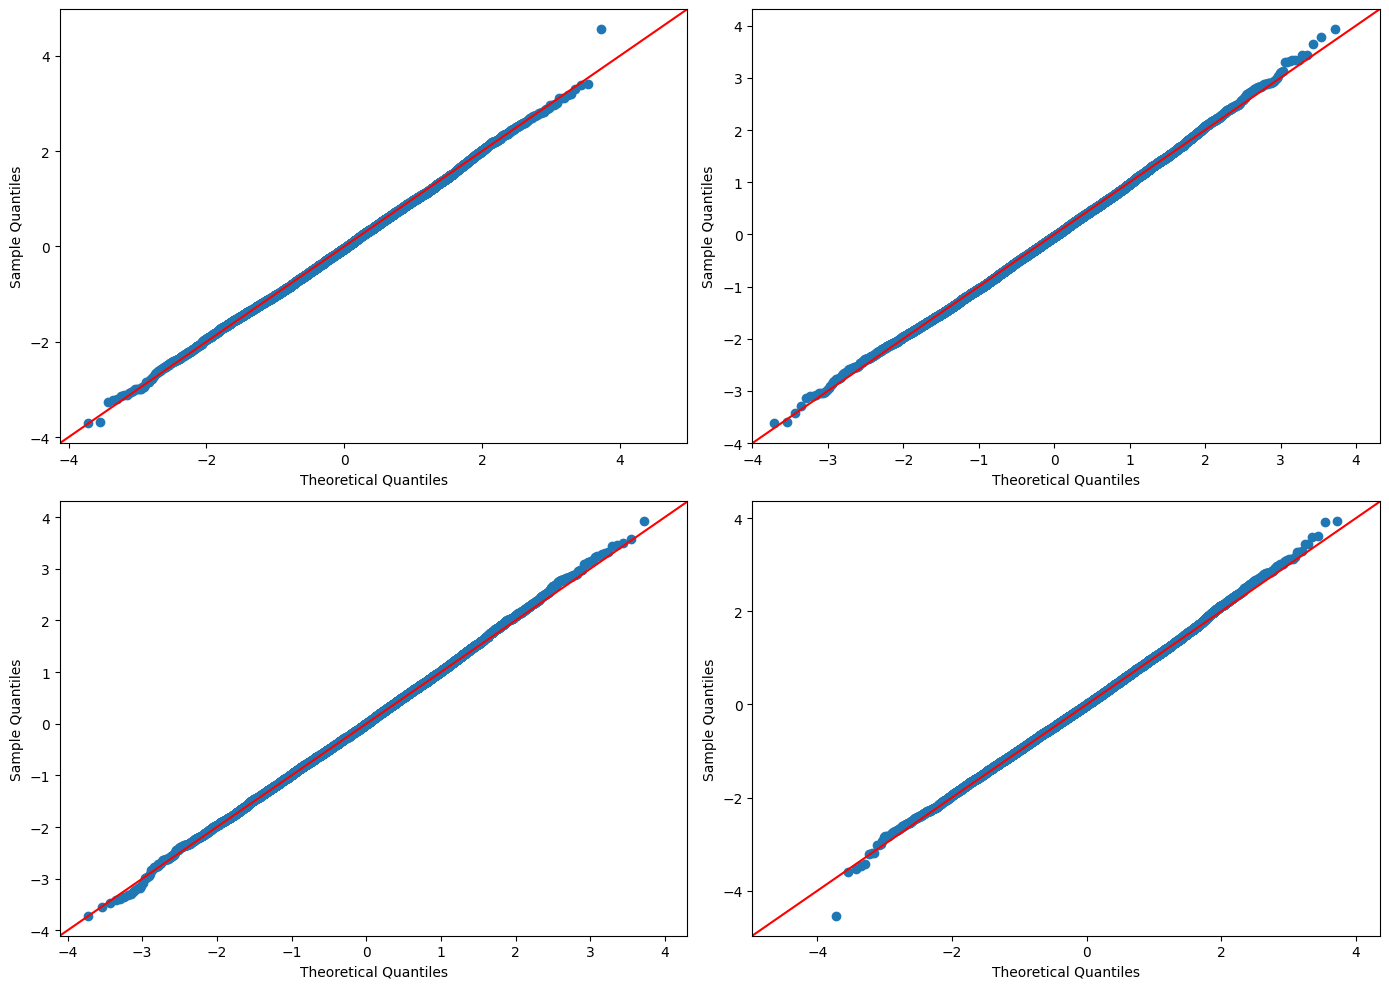

In [29]:
import statsmodels.api as sm

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (name, values), title in zip(axes, results.items(), titles):
    sample_var = np.var(values, ddof=1)
    theor_var = theoretical_vars[name]
    values_theor = values / np.sqrt(theor_var)
    sm.qqplot(values_theor, line='45', ax=ax)

plt.tight_layout()
plt.show()

**Вопрос:** Какие оценки оказались асимптотически нормальными? Совпали ли ваши предположения о свойстве оценок с визуальной проверкой qqplot?

Все четыре оценки асимптотически нормальны: гистограммы $\sqrt{n}(\hat{\theta}-\theta)$ приближаются к нормальной кривой, а qqplot близок к прямой линии. Предположения подтвердились: все оценки состоятельны и асимптотически нормальны, что соответствует теории

## Задача 4

В файле *hops_barley.txt* представлены данные о 137 замерах длин соцветий хмеля и ячменя в период созревания (в сантиметрах). Для удобства данные центрированы (примерно нулевое среднее). Загрузите данные и визуализируйте их

Размер выборок: хмель – 137, ячмень – 137
Среднее хмеля: -0.067, ячменя: -0.177


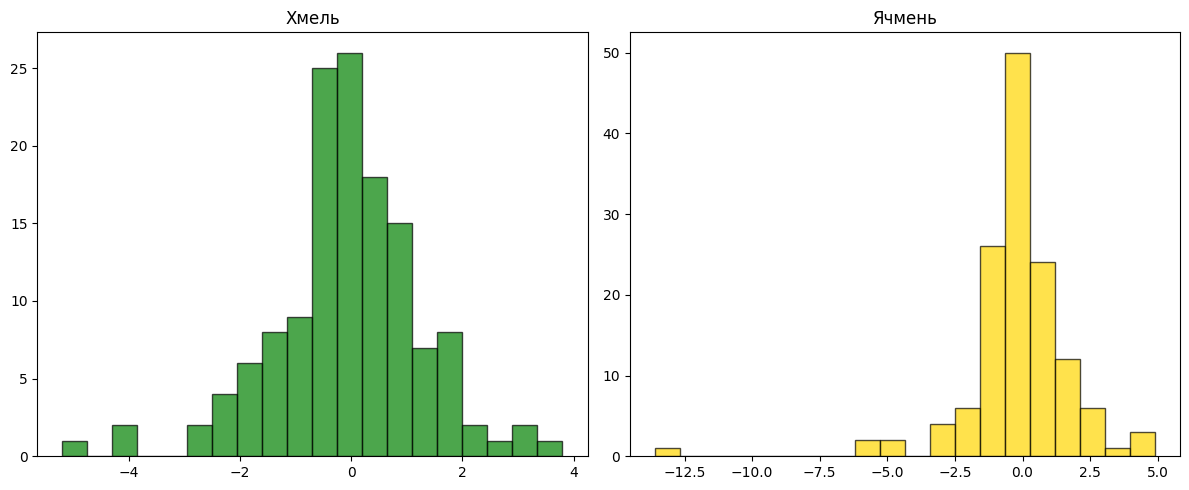

In [31]:
data = np.loadtxt('hops_barley.txt', skiprows=1)
hops = data[:,0]
barley = data[:,1]

print(f'Размер выборок: хмель – {len(hops)}, ячмень – {len(barley)}')
print(f'Среднее хмеля: {np.mean(hops):.3f}, ячменя: {np.mean(barley):.3f}')

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(hops, bins=20, alpha=0.7, color='green', edgecolor='black')
plt.title('Хмель')
plt.subplot(1,2,2)
plt.hist(barley, bins=20, alpha=0.7, color='gold', edgecolor='black')
plt.title('Ячмень')
plt.tight_layout()
plt.show()

Для каждого растения предположите, какому однопараметрического семейству $F_{\theta}$ с нулевым матожиданием могут принадлежать данные измерений. Подкрепите свои выводы гистограммой и qqplot

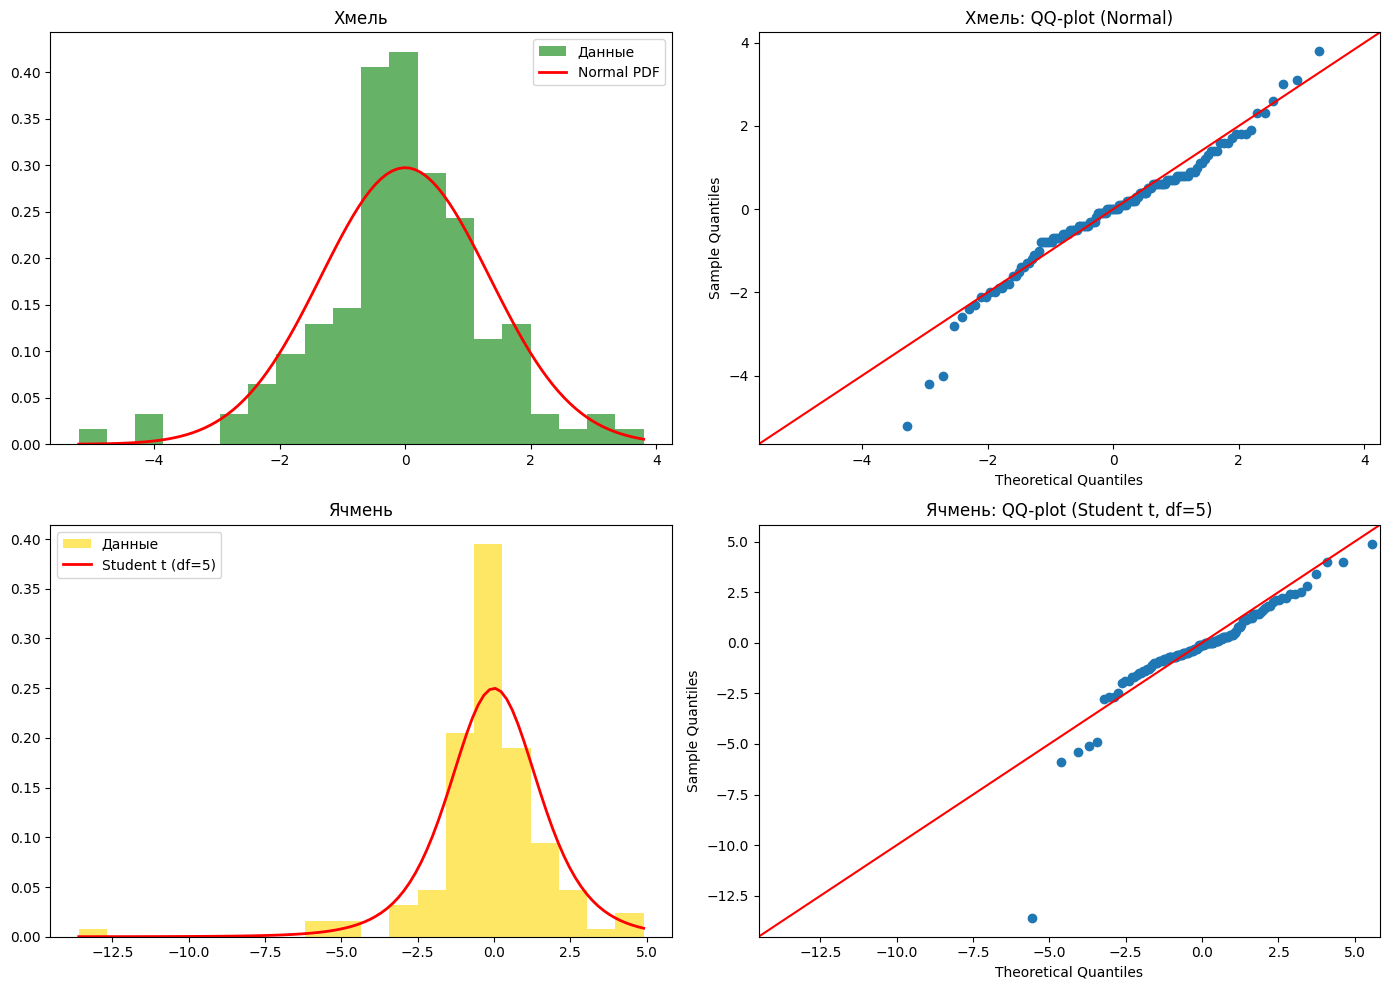

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sigma_h = np.std(hops)
x_h = np.linspace(min(hops), max(hops), 100)
axes[0, 0].hist(hops, bins=20, density=True, alpha=0.6, color='green', label='Данные')
axes[0, 0].plot(x_h, stats.norm.pdf(x_h, 0, sigma_h), 'r-', lw=2, label='Normal PDF')
axes[0, 0].set_title('Хмель')
axes[0, 0].legend()

sm.qqplot(hops, stats.norm, loc=0, scale=sigma_h, line='45', ax=axes[0, 1])
axes[0, 1].set_title('Хмель: QQ-plot (Normal)')

df_barley = 5
scale_b = np.std(barley) * np.sqrt((df_barley - 2) / df_barley) if df_barley > 2 else np.std(barley)
x_b = np.linspace(min(barley), max(barley), 100)
axes[1, 0].hist(barley, bins=20, density=True, alpha=0.6, color='gold', label='Данные')
axes[1, 0].plot(x_b, stats.t.pdf(x_b, df=df_barley, loc=0, scale=scale_b), 'r-', lw=2, label=f'Student t (df={df_barley})')
axes[1, 0].set_title('Ячмень')
axes[1, 0].legend()

sm.qqplot(barley, stats.t, distargs=(df_barley,), loc=0, scale=scale_b, line='45', ax=axes[1, 1])
axes[1, 1].set_title(f'Ячмень: QQ-plot (Student t, df={df_barley})')

plt.tight_layout()
plt.show()

Постройте оценку для параметра распределения $\theta$ и проверьте, обладает ли она какими-нибудь полезными свойствами

In [33]:
theta_hops_est = np.sqrt(np.mean(hops**2))

df_b = 5
theta_barley_est = np.sqrt(np.var(barley) * (df_b - 2) / df_b)

print(f'Оценка параметра для хмеля: {theta_hops_est:.4f}')
print(f'Оценка параметра для ячменя: {theta_barley_est:.4f}')

Оценка параметра для хмеля: 1.3435
Оценка параметра для ячменя: 1.5189


**Вопрос:** Какое распределение выбрали в качестве семейства? Какие получились оценки для выборок? Какими свойствами обладают полученные оценки?

 Хмель: Нормальное распределение $\mathcal{N}(0, \sigma^2)$.  
 Ячмень: Распределение Стьюдента $t(\nu)$ с $\nu=5$.  
 Обе оценки для нормального распределения и для распределения Стьюдента через моменты являются состоятельными и асимптотически нормальными.